# Reusable Control Panel

The goal of this notebook is to contain all of the nitty-gritty configuration and control code interfaces to the AFL. It is heavily recommended that you use the Table of Contents panel at left to interact with this notebook. 

In [11]:
%run afl_notebook_setup.ipy

Set up AFL client for Robot OT2 under variable robot_client
Set up AFL client for Orchestrator under variable orch_client


Set up AFL client for AFL Agent under variable agent_client
Set up AFL client for Loader under variable load_client
Starting connection to the AFL tiled server...


# Robot Pipettor

## Configure Connection

In [8]:
robot_client.enqueue(task_name='home')

'QD-96ec498f-a566-4085-be86-f57adc120318'

In [36]:
robot_client.enqueue(task_name='set_gantry_speed',speed=400,interactive=False)

'QD-99130770-1cfa-400c-9eb5-64b28f5742f3'

In [39]:
robot_client.enqueue(task_name='make_align_script',filename='align.py')

'QD-f92f4e20-bc01-41af-a0d5-fe773b842048'

## Transfer Configuration 

### Protocol for Transferring to Catch

In [13]:
catch_protocol = dict(
    source='target',
    dest='10A1',
    volume = 900,
    post_aspirate_delay = 5,
    post_dispense_delay = 5,
    aspirate_rate = 100, 
    dispense_rate = 100,
    mix_before = (3,400),
    mix_aspirate_rate=150,
    mix_dispense_rate=150,
)
robot.set_config(catch_protocol=catch_protocol)

'QD-f65bb9ec-bb07-4225-bb3b-d7878e1bf0d1'

### Mix Order

In [12]:
stock_mix_order =  [
    'stock_H2O',
    'stock_TM50',
    'stock_HS40'
    'stock_PEG6k'
    'stock_PEG20k'
]
robot_client.set_config(stock_mix_order=stock_mix_order)

'QD-5e70b818-3801-495f-8ea5-f9cf8a6508c7'

### Individual Stock Pipette Settings 

In [14]:
stock_transfer_params = {}
for stock in stock_mix_order:
    stock_transfer_params[stock] = {
        'post_aspirate_delay':5, 
        'post_dispense_delay':5, 
        'aspirate_rate':100, 
        'dispense_rate':100 
    }  
    
# stock_transfer_params['stock_SiO2'] =  {
#     'post_aspirate_delay':2, 
#     'post_dispense_delay':2, 
#     'aspirate_rate':150, 
#     'dispense_rate':150,
#     'aspirate_equilibration_delay':1
# }
    
robot_client.set_config(stock_transfer_params=stock_transfer_params)

'QD-686558cf-77e1-4eb3-a7be-ad6b65c304c8'

## Manual Pipettor

In [61]:
protocol = PipetteAction(
    source='4A1',
    dest='4A1',
    volume = 800,
    post_aspirate_delay = 1,
    post_dispense_delay = 1,
    aspirate_rate = 50, 
    dispense_rate = 50,
    mix_before = None,
    mix_aspirate_rate=100,
    mix_dispense_rate=100,
)
robot_client.enqueue(task_name='transfer',**protocol.emit_protocol())

'QD-3937402f-b89a-4fc7-8152-87533818a612'

# Define NEST 1.6ml labware

In [58]:
import json
with open('/home/beams/USAXS/Apps/AFL/nest_96_wellplate_1.6ml_deep_AFL.json','r') as f:
    labware_def = json.load(f)


In [59]:
robot_client.enqueue(task_name='send_labware', labware_def = labware_def)

'QD-fac6a648-325d-4abc-945b-90773702de15'

# Orchestrator Server

## Configure Connection

## Specify Clients

In [14]:
client_dict = {
    'prep':'usaxscontrol:5002',
    'load':'afl-loader:5000',
    # 'agent':'usaxscontrol:5051',
    'inst':'usaxscontrol:5000',
    #'turb':'localhost:5001'
}
orch_client.set_config(client=client_dict)

'QD-d6439eb4-4c9f-4ce3-b80f-67cac0e84411'

## Specify Instruments

In [34]:
instrument = [
    {
        'name':'APSUSAXS',
        'client_name':'inst',
        'load_dest_label':'afterUSAXS',
        'sample_dim':'saxs_sample',
        'sample_comps_variable':'saxs_comps',
        'empty_base_kw': {'task_name': 'expose'},
        'measure_base_kw': {'task_name': 'expose'},
        'data': [
            {'data_name':'USAXS_I','tiled_array_name':'USAXS_I','data_dim':'USAXS_q', 'tiled_metadata_dim': 'USAXS_q'},
            {'data_name':'USAXS_dI','tiled_array_name':'USAXS_dI','data_dim':'USAXS_q', 'tiled_metadata_dim': 'USAXS_q'},
            {'data_name':'SAXS_I','tiled_array_name':'SAXS_I','data_dim':'SAXS_q', 'tiled_metadata_dim': 'SAXS_q'},
            {'data_name':'SAXS_dI','tiled_array_name':'SAXS_dI','data_dim':'SAXS_q', 'tiled_metadata_dim': 'SAXS_q'},
        ],
        # 'quality_metric': {'tiled_metadata_key':'transmission','comparison':'<','threshold':0.7} #

                            
    }, 
]
orch_client.set_config(instrument=instrument)

'QD-af56acd7-0111-4e92-9edb-a8c1d61e09ee'

In [13]:
orch_client.enqueue(task_name='validate_config')

'QD-d04d05aa-1a97-4ec4-9d26-d200affec8f7'

# USAXS Instrument

## Configure Connection

In [7]:
# inst_client = Client('192.168.0.210','5000')
inst_client = Client('localhost','5000')
inst_client.login('nb')

## Manual Exposure

In [8]:
inst_client.enqueue(task_name='expose',name='WaterCapillaryAFLTest')

'QD-fe1af257-7fb5-4c62-a330-cd5eae2973c3'

In [29]:
inst_client.enqueue(task_name='expose',name='AFLBlankTest')

'QD-9f64666e-6e0e-441a-8420-97bc5aad1cc5'

In [ ]:
inst_client.enqueue(task_name='measureTransmission',set_empty_transmission=True)

In [ ]:
inst_client.set_config(wavelength=1.34e-10,dist=3.5,interactive=False)

# Sample Loader

## Basic load_client Commands

In [19]:
load_client.enqueue(task_name='loadSample',load_dest_label='afterUSAXS')

'QD-9ef4c2b0-b044-4204-aac8-d363b8043c4c'

In [226]:
load_client.enqueue(task_name='advanceSample',load_dest_label='afterUSAXS')

'QD-84c473ce-1da0-4ca3-b604-87f9de7f77c3'

In [87]:
load_client.enqueue(task_name='set_sample',sample_name='test')

'QD-41a03e8d-ea6f-4087-b134-9efbe4c4e49b'

In [14]:
load_client.enqueue(task_name='rinseCell')

'QD-48b7e521-ea04-4d48-a71c-50330edd97c4'

In [33]:
load_client.enqueue(task_name='calibrate_sensor')

'QD-c1e4d6d4-5579-4a31-aca5-93813a4a2987'

In [194]:
# load_client.enqueue(task_name='_arm_down',interactive=True)

{'ended': '06/12/25 20:22:24-135283 ',
 'exit_state': 'Success!',
 'queued': '06/12/25 20:22:23-310974',
 'return_val': None,
 'run_time_minutes': 0.0,
 'run_time_seconds': 0,
 'started': '06/12/25 20:22:23-317194 '}

In [195]:
# load_client.enqueue(task_name='_arm_up',interactive=True)

{'ended': '06/12/25 20:22:50-630919 ',
 'exit_state': 'Success!',
 'queued': '06/12/25 20:22:49-761248',
 'return_val': None,
 'run_time_minutes': 0.0,
 'run_time_seconds': 0,
 'started': '06/12/25 20:22:49-764830 '}

## Configure Loader

In [36]:
load_client.get_config("all",interactive=True)

{'ended': '11/23/25 11:36:19-973202 ',
 'exit_state': 'Success!',
 'queued': '11/23/25 11:35:43-124376',
 'return_val': {'arm_move_delay': 0.2,
  'blowout_pressure': 20,
  'external_load_complete_trigger': False,
  'load_mode': 'ramp',
  'load_pressure': 2,
  'load_timeout': 120,
  'ramp_load_duration': 40,
  'ramp_load_stop_pressure': 8,
  'rinse_program': [['rinse1', 5],
   [None, 2],
   ['rinse2', 5],
   [None, 2],
   ['rinse1', 5],
   [None, 2],
   ['rinse2', 5],
   [None, 2],
   ['blow', 5],
   [None, 5],
   ['blow', 10],
   [None, 5],
   ['blow', 10]],
  'vent_delay': 0.5},
 'run_time_minutes': 0.0,
 'run_time_seconds': 0,
 'started': '11/23/25 11:36:19-841138 '}

In [37]:
rinse_program = [ 
    ['rinse1', 10], 
    [None, 2], 
    ['rinse2', 10], 
   [None, 2],
    ['rinse1', 20], 
    [None, 2], 
    ['rinse2', 20], 
   [None, 2],
   ['blow', 20],
   [None, 5],
   ['blow', 20],
   [None, 5],
   ['blow', 20],
    [None, 5],
   ['blow', 20],
]
load_client.set_config(rinse_program=rinse_program)

'QD-1c6f135f-dfa2-458b-aa5c-a4548aa5e2c2'

In [29]:
rinse_program = [ 
    ['rinse1', 5], 
    [None, 2], 
    ['rinse2', 5], 
    [None, 2],
    ['rinse1', 5], 
    [None, 2], 
    ['rinse2', 5], 
   [None, 2],
   ['blow', 5],
   [None, 5],
   ['blow', 10],
   [None, 5],
   ['blow', 10],
]
load_client.set_config(rinse_program=rinse_program)

'QD-c6a927e8-3cd4-4422-a300-656d0b326d67'

In [39]:
rinse_program = [  
    ['rinse1', 5], 
    [None, 2], 
    ['rinse2', 5], 
    [None, 2],
    ['blow', 5],
    [None, 2],
    ['blow', 5],
    [None, 2]
]
load_client.set_config(rinse_program=rinse_program)

'QD-53d39359-dc62-4c88-ba88-fc176c9d0853'

In [12]:
rinse_program = [  
    ['blow', 20],
    [None, 2],
    ['blow', 20],
    [None, 2],
    ['blow', 20],
    [None, 2],
    ['blow', 20],
    [None, 2],
    ['blow', 20],
    [None, 2],
    ['blow', 20],
    [None, 2],
    ['blow', 20],
    [None, 2],
    ['blow', 20],
    [None, 2]
]
load_client.set_config(rinse_program=rinse_program)

'QD-8de93f81-7e6b-4e58-9523-50798de75a99'

In [25]:
load_client.enqueue(task_name='calibrate_sensor')

'QD-c51ec070-1e16-4ea4-ab61-e6a515dc6d42'

In [94]:
load_client.enqueue(task_name="set_sample",sample_name="debug")

'QD-8631c2c6-95fc-4c64-8f63-19611fd74957'

## Configure LoadStopper

In [21]:
load_client.enqueue(task_name='get_sensor_config',interactive=True)

{'ended': '11/22/25 21:39:38-906444 ',
 'exit_state': 'Success!',
 'queued': '11/22/25 21:39:38-819235',
 'return_val': [{'load_speed': 2,
   'period': 0.05,
   'poll_window': 1000,
   'sensorlabel': '',
   'stopper_baseline_duration': 2,
   'stopper_filepath': '/home/pi/.afl/loadstopper_data',
   'stopper_loadstop_cooldown': 2,
   'stopper_min_load_time': 3,
   'stopper_post_detection_sleep': 1,
   'stopper_threshold_npts': 50,
   'stopper_threshold_std': 3.0,
   'stopper_threshold_v_step': 1,
   'stopper_timeout': 120}],
 'run_time_minutes': 0.0,
 'run_time_seconds': 0,
 'started': '11/22/25 21:39:38-822532 '}

In [23]:
sensor_config = {'load_speed': 2,
   'period': 0.05,
   'poll_window': 1000,
   'sensorlabel': '',
   'stopper_baseline_duration': 2,
   'stopper_filepath': '/home/pi/.afl/loadstopper_data',
   'stopper_loadstop_cooldown': 2,
   'stopper_min_load_time': 3,
   'stopper_post_detection_sleep': 0.1,
   'stopper_threshold_npts': 50,
   'stopper_threshold_std': 3.0,
   'stopper_threshold_v_step': 1,
   'stopper_timeout': 120}


load_client.enqueue(task_name='set_sensor_config',**sensor_config)

'QD-6d4bfc0f-6189-471e-9ed8-9efce27d8802'

## Plot LoadStopper

In [210]:
!rsync -Pavh pi@afl-loader:~/.afl/loadstopper_data/ ~/.afl/loadstopper_data/

receiving incremental file list
./
Sensor-250612-20:58:02.txt
         99.40K 100%   94.80MB/s    0:00:00 (xfr#1, to-chk=1/14)
Sensor-250612-21:12:08.txt
         58.70K 100%    3.11MB/s    0:00:00 (xfr#2, to-chk=0/14)

sent 65 bytes  received 158.66K bytes  317.45K bytes/sec
total size is 724.26K  speedup is 4.56


In [211]:
import xarray as xr
import matplotlib.pyplot as plt
import pathlib
import datetime

base_path = pathlib.Path('/home/beams/USAXS/.afl/loadstopper_data/')

ds_list = []
for file in base_path.glob('*txt'):
    x,y = np.loadtxt(file).T

    name,date,time = file.stem.split('-')
    time = time.split('.')[0]

    ds = xr.Dataset()
    ds['dt'] = ('dt',x)
    ds['signal'] = ('dt',y)
    ds['time'] = datetime.datetime.strptime(date+" "+time,'%y%m%d %H:%M:%S')
    ds_list.append(ds)

ds = xr.concat(ds_list,dim='time')
ds = ds.sortby('time')
ds


/home/beams/USAXS/.conda/envs/AFL_agent/lib/python3.11/site-packages/xarray/structure/concat.py:540: UserWarning: No index created for dimension time because variable time is not a coordinate. To create an index for time, please first call `.set_coords('time')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


<xarray.Dataset> Size: 2MB
Dimensions:  (time: 13, dt: 14482)
Coordinates:
  * time     (time) datetime64[ns] 104B 2025-05-24T02:08:05 ... 2025-06-12T21...
  * dt       (dt) float64 116kB 0.000946 0.001565 0.001868 ... 119.9 120.0 120.0
Data variables:
    signal   (time, dt) float64 2MB nan nan nan nan nan ... nan nan nan nan nan

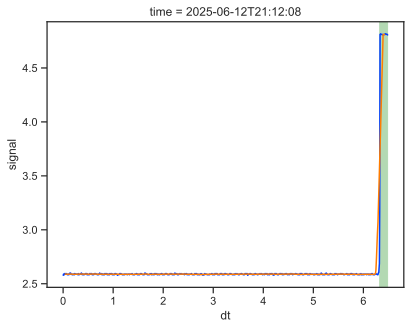

In [212]:
def get_true_regions(x,signal):
    regions = []
    in_region = False
    for i in range(len(signal)):
        if signal[i] and not in_region:
            start = x[i]
            in_region = True
        elif not signal[i] and in_region:
            end = x[i]
            regions.append((start,end))
            in_region=False
    if in_region:
        regions.append((start,x[-1]))
    return regions

def plot_bool_signal(x,signal,color='red'):
    for start,end in get_true_regions(x,signal):
        plt.gca().axvspan(start,end,color=color,alpha=0.3)
        
# config = {
#   'load_speed': 2,
#    'period': 0.001,
#    'poll_window': 10000,
#    'stopper_baseline_duration': 2,
#    'stopper_filepath': '/home/pi/.afl/loadstopper_data',
#    'stopper_loadstop_cooldown': 2,
#    'stopper_min_load_time': 0.5,
#    'stopper_post_detection_sleep': 0.0,
#    'stopper_threshold_npts': 50,
#    'stopper_threshold_std': 0.50,
#    'stopper_threshold_v_step': 0.2,
#    'stopper_timeout': 60
# }

config = {'load_speed': 2,
   'period': 0.05,
   'poll_window': 1000,
   'sensorlabel': '',
   'stopper_baseline_duration': 2,
   'stopper_filepath': '/home/pi/.afl/loadstopper_data',
   'stopper_loadstop_cooldown': 2,
   'stopper_min_load_time': 3,
   'stopper_post_detection_sleep': 1,
   'stopper_threshold_npts': 20,
   'stopper_threshold_std': 3.0,
   'stopper_threshold_v_step': 1,
   'stopper_timeout': 120}            
        
ds1 = ds.isel(time=-1).dropna('dt').copy()
signal = ds1.signal
mean = signal.dropna('dt').rolling(dt=config['stopper_threshold_npts'],center=True).mean()
std = signal.dropna('dt').rolling(dt=config['stopper_threshold_npts'],center=True).std()


baseline_npts = int(config['stopper_baseline_duration']/config['period'])
baseline = mean.isel(dt=slice(None,baseline_npts)).mean()

small_v_step = (mean-baseline)<config['stopper_threshold_v_step']
large_std = (std)>config['stopper_threshold_std']
too_soon = (signal.dt - signal.dt[0])<config['stopper_min_load_time']

stop = np.logical_and(~too_soon,~np.logical_or(small_v_step,large_std))

ds1.signal.dropna('dt').plot()
mean.plot()
#plot_bool_signal(sig1.dt,sig1,color='red')
#plot_bool_signal(sig1.dt,sig2,color='green')
plot_bool_signal(signal.dt,stop,color='green')




# Tiled Database

In [9]:
from tiled.client import from_uri
from tiled.queries import Eq,Contains, NotIn, Regex

tiled_client = from_uri('http://usaxscontrol:8007',api_key='c8404a06029223c1126ccb5136d1556a4b0dcf6514a2ff196cb9372264384a90')
tiled_client

<Container {'ee407af5-3e35-4330-9041-ef73c3a25574', ...} ~6 entries>

In [31]:
res = tiled_client.search(Eq('array_name','USAXS_I'))
for uid in res:
    if 'sample_uuid' in tiled_client[uid].metadata:
        print(tiled_client[uid].metadata['array_name'],tiled_client[uid].metadata['sample_uuid'],)

USAXS_I SAM-48160fbb-1e7f-4dc5-97ac-eeef5ea6b389
USAXS_I SAM-a29a1df9-12d2-45ad-a027-fccbb2b5956b


## Plot Loadstopper

In [ ]:
for _,array in list(tiled_client.search(Eq('task_name','loadSample')).items()):
    pass

In [40]:
ds_list = []
for _,array in list(tiled_client.search(Eq('load_dest_label','afterUSAXS')).items()):
    label = 'afterSAXS_load_stop_trace'
    try:
        x,y = np.array(array.metadata[label]).T
        date = array.metadata['meta']['ended']
    except KeyError:
        continue
    else:
        ds = xr.Dataset()
        ds['dt'] = ('dt',x)
        ds['signal'] = ('dt',y)
        ds['trigger_voltage'] = array.metadata['afterSAXS_first_trigger_voltage']
        ds['trigger_time'] = array.metadata['afterSAXS_elapsed_time_at_first_trigger']
        ds['time'] = datetime.datetime.strptime(date.strip(),'%m/%d/%y %H:%M:%S-%f')
        ds_list.append(ds)

ds = xr.concat(ds_list,'time') 
ds


ValueError: must supply at least one object to concatenate

In [ ]:
def get_true_regions(x,signal):
    regions = []
    in_region = False
    for i in range(len(signal)):
        if signal[i] and not in_region:
            start = x[i]
            in_region = True
        elif not signal[i] and in_region:
            end = x[i]
            regions.append((start,end))
            in_region=False
    if in_region:
        regions.append((start,x[-1]))
    return regions

def plot_bool_signal(x,signal,color='red'):
    for start,end in get_true_regions(x,signal):
        plt.gca().axvspan(start,end,color=color,alpha=0.3)
        
config = {
  'load_speed': 2,
   'period': 0.001,
   'poll_window': 10000,
   'stopper_baseline_duration': 2,
   'stopper_filepath': '/home/pi/.afl/loadstopper_data',
   'stopper_loadstop_cooldown': 2,
   'stopper_min_load_time': 0.5,
   'stopper_post_detection_sleep': 0.0,
   'stopper_threshold_npts': 50,
   'stopper_threshold_std': 0.50,
   'stopper_threshold_v_step': 0.2,
   'stopper_timeout': 60
}

ds1 = ds.isel(time=-1).dropna('dt').copy()
signal = ds1.signal
mean = signal.dropna('dt').rolling(dt=config['stopper_threshold_npts'],center=True).mean()
std = signal.dropna('dt').rolling(dt=config['stopper_threshold_npts'],center=True).std()


baseline_npts = int(config['stopper_baseline_duration']/config['period'])
baseline = mean.isel(dt=slice(None,baseline_npts)).mean()

small_v_step = (mean-baseline)<config['stopper_threshold_v_step']
large_std = (std)>config['stopper_threshold_std']
too_soon = (signal.dt - signal.dt[0])<config['stopper_min_load_time']

stop = np.logical_and(~too_soon,~np.logical_or(small_v_step,large_std))

ds1.signal.dropna('dt').plot()
mean.plot()
#plot_bool_signal(sig1.dt,sig1,color='red')
#plot_bool_signal(sig1.dt,sig2,color='green')
plot_bool_signal(ds1.dt,stop,color='green')

plt.axvline(ds1.trigger_time,color='red',ls=':')
plt.axhline(ds1.trigger_voltage,color='red',ls=':')

